In [1]:
import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

I0000 00:00:1791373282.540196    6251 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
!wget 'https://cainvas-static.s3.amazonaws.com/media/user_data/cainvas-admin/arabic.zip'

--2026-10-07 00:37:52--  https://cainvas-static.s3.amazonaws.com/media/user_data/cainvas-admin/arabic.zip
Resolving cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)... 3.5.209.23, 52.219.158.59, 16.12.36.95, ...
Connecting to cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)|3.5.209.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25159080 (24M) [application/x-zip-compressed]
Saving to: ‘arabic.zip’

arabic.zip          100%[===================>]  23.99M  3.45MB/s    in 7.2s    

2026-10-07 00:38:00 (3.36 MB/s) - ‘arabic.zip’ saved [25159080/25159080]



In [2]:
train = pd.read_csv('arabic/csvTrainImages 13440x1024.csv')
test = pd.read_csv('arabic/csvTestImages 3360x1024.csv')
train_label  =pd.read_csv('arabic/csvTrainLabel 13440x1.csv')
test_label  =pd.read_csv('arabic/csvTestLabel 3360x1.csv')

In [3]:
print("Training Images Shape = ", train.shape)
print("Testing Images Shape = ", test.shape)
print("Training Labels Shape = ", train_label.shape)
print("Testing Labels Shape = ", test_label.shape)

Training Images Shape =  (13439, 1024)
Testing Images Shape =  (3359, 1024)
Training Labels Shape =  (13439, 1)
Testing Labels Shape =  (3359, 1)


In [4]:
train = np.array(train)
test = np.array(test)
train_label = np.array(train_label)
test_label = np.array(test_label)

In [5]:
X = train 
y0 = train_label 
binencoder = LabelBinarizer()
y = binencoder.fit_transform(y0)

In [6]:
X_images = X.reshape(-1, 32, 32)
test_images = test.reshape(-1, 32, 32)

In [7]:
print(X_images.shape)
print(test_images.shape)

(13439, 32, 32)
(3359, 32, 32)


In [8]:
def visualize_images(df, img_size, number_of_images, name):
    plt.figure(figsize=(8,8))

    n_rows = df.shape[0] 
    f = plt.figure(figsize=(15,15))
    reshaped_df = df.reshape(df.shape[0], img_size, img_size)
    number_of_rows = number_of_images // 5 if number_of_images % 5 == 0 else (number_of_images // 5) + 1
    for i in range(number_of_images):
        f.add_subplot(number_of_rows, 5, i+1, xticks=[], yticks=[])
        plt.title(np.argmax(name[i]), color='blue', fontdict={'size':'25'})
        plt.imshow(reshaped_df[i], cmap='gray')

<Figure size 800x800 with 0 Axes>

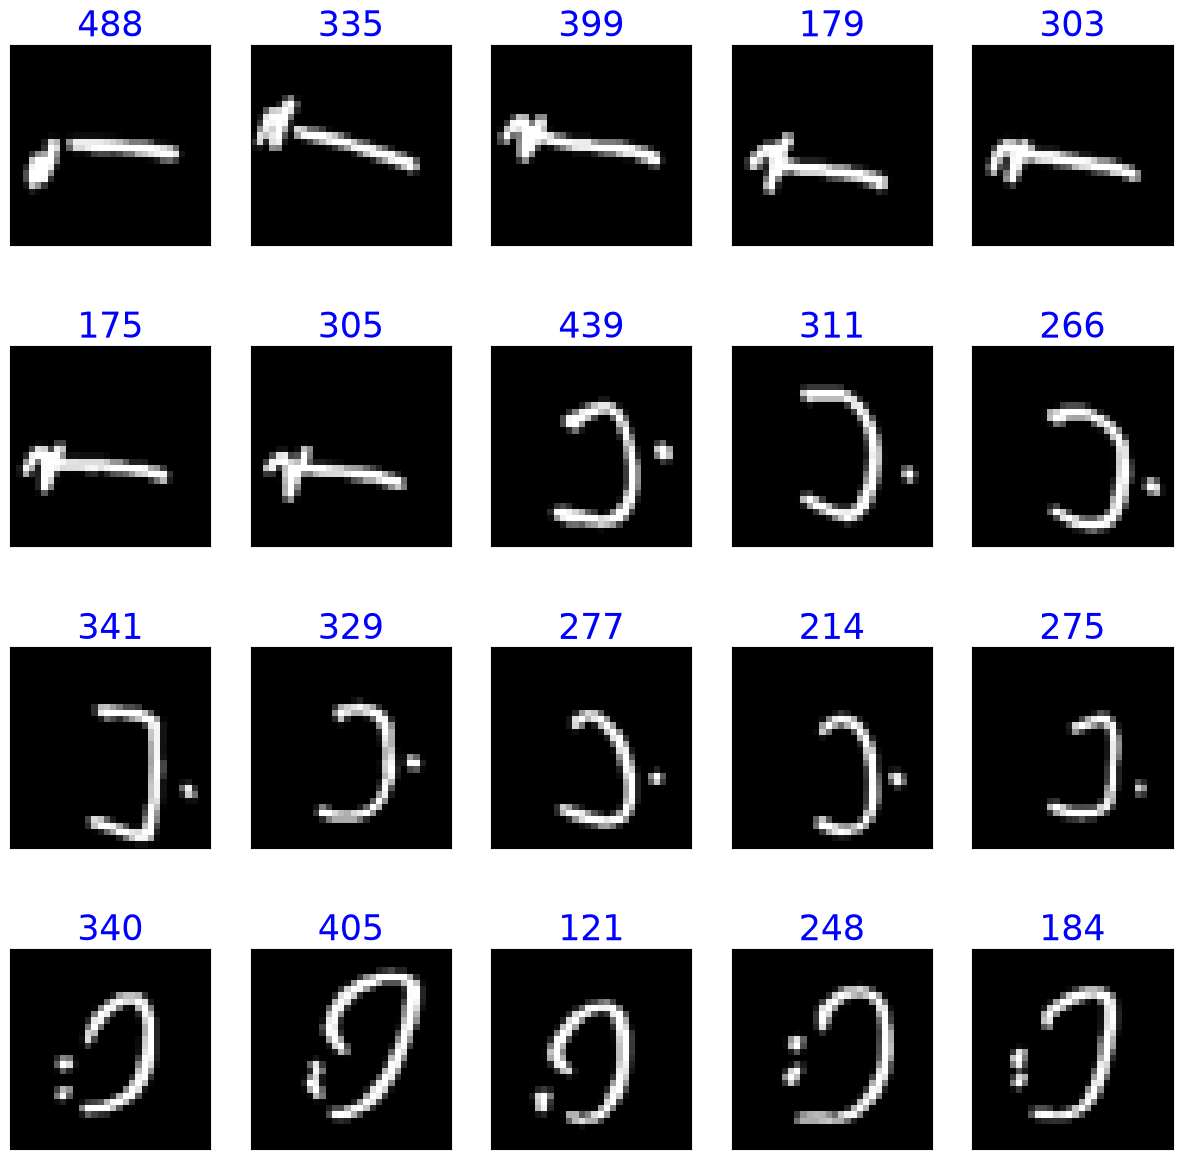

In [9]:
visualize_images(X_images, 32, 20, test_images)

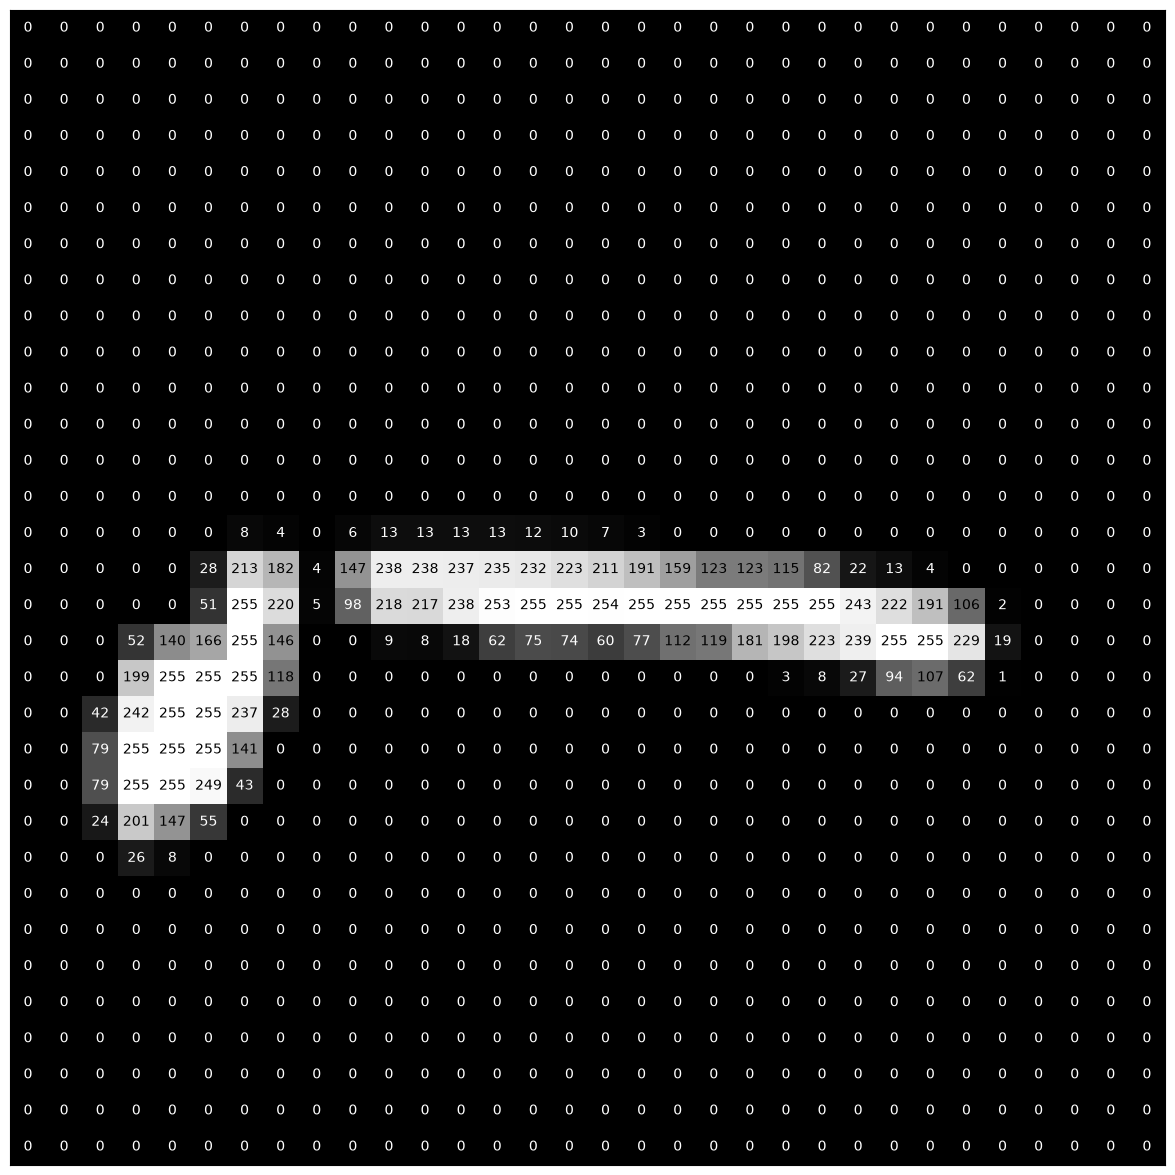

In [10]:
def visualize_input(img, ax):
    img = img.reshape(32,32)
    ax.imshow(img, cmap='gray')
    width, height = img.shape
    thresh = img.max() / 2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y],2)), xy=(y,x),horizontalalignment='center', verticalalignment='center', color='white' if img[x][y] < thresh else 'black')
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111, xticks=[], yticks=[])
visualize_input(X_images[0], ax)

In [11]:
X_train= X_images / 255.0
X_test = test_images / 255.0

X_train = X_train.reshape(-1, 32,32,1).astype('float32')
X_test = X_test.reshape(-1, 32,32,1).astype('float32')

In [15]:
es = EarlyStopping(monitor='val_loss', patience=5)
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32, 32,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32,(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32,(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(36,activation='relu'))
model.add(Dense(36,activation='relu'))
model.add(Dropout(0.2))

y_train = binencoder.fit_transform(train_label)
y_test = binencoder.transform(test_label)


model.add(Dense(28, activation='softmax'))
model.summary()

/home/ubuntu24/PROJECTS/Recognise-Arabic-Digits-Project/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         4,644 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 36)             │         1,332 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 28)             │         1,036 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,828 (100.89 KB)

 Trainable params: 25,828 (100.89 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [17]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=50, epochs=100, callbacks=[es])

Epoch 1/100


W0000 00:00:1791373947.490435    6251 cpu_allocator_impl.cc:82] Allocation of 55046144 exceeds 10% of free system memory.


  5/269 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.0240 - loss: 3.3337

W0000 00:00:1791373949.165383    7669 cpu_allocator_impl.cc:82] Allocation of 24336000 exceeds 10% of free system memory.
W0000 00:00:1791373949.165390    7668 cpu_allocator_impl.cc:82] Allocation of 24336000 exceeds 10% of free system memory.
W0000 00:00:1791373949.206569    7666 cpu_allocator_impl.cc:82] Allocation of 24336000 exceeds 10% of free system memory.
W0000 00:00:1791373949.206649    7664 cpu_allocator_impl.cc:82] Allocation of 24336000 exceeds 10% of free system memory.


269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.1587 - loss: 2.7909 - val_accuracy: 0.4355 - val_loss: 1.8123
Epoch 2/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.3976 - loss: 1.7674 - val_accuracy: 0.5948 - val_loss: 1.2109
Epoch 3/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.5278 - loss: 1.3359 - val_accuracy: 0.7044 - val_loss: 0.8851
Epoch 4/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6160 - loss: 1.0820 - val_accuracy: 0.7589 - val_loss: 0.7099
Epoch 5/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.6773 - loss: 0.9352 - val_accuracy: 0.7862 - val_loss: 0.6270
Epoch 6/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.7169 - loss: 0.8142 - val_accuracy: 0.8223 - val_loss: 0.5436
Epoch 7/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7488 - loss: 0.7310 - val_accuracy: 0.8178 - val_loss: 0.5557
Epoch 8/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7762 - loss: 0.6755 - val_accura

In [18]:
def plot_metrics(model_name, metric='accuracy'):
    if metric == 'loss':
        plt.title("Loss Values")
        plt.plot(model_name.history['loss'], label='train')
        plt.plot(model_name.history['val_loss'], label='test')
        plt.legend()
        plt.show()
    else:
        plt.title("Accuracy Values")
        plt.plot(model_name.history['accuracy'], label='train')
        plt.plot(model_name.history['val_accuracy'], label='train')
        plt.legend()
        plt.show()

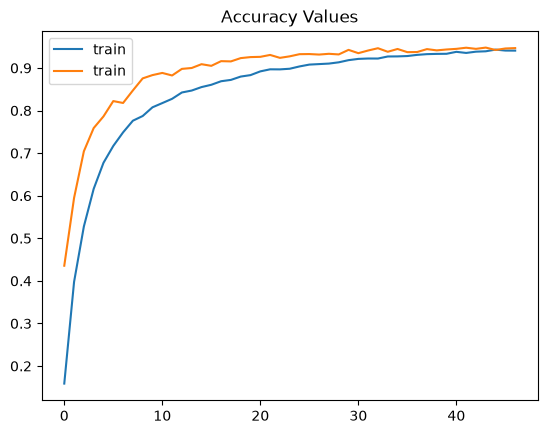

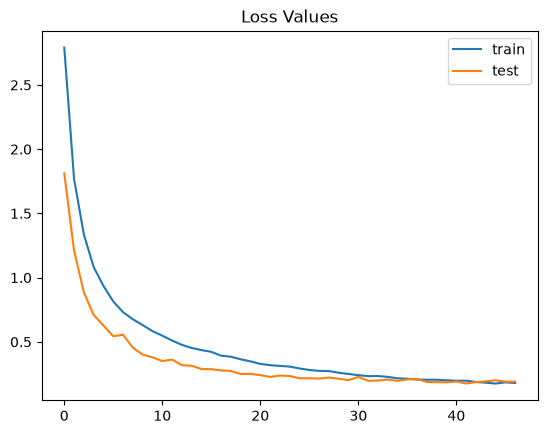

In [19]:
plot_metrics(history, 'accuracy')
plot_metrics(history, 'loss')

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


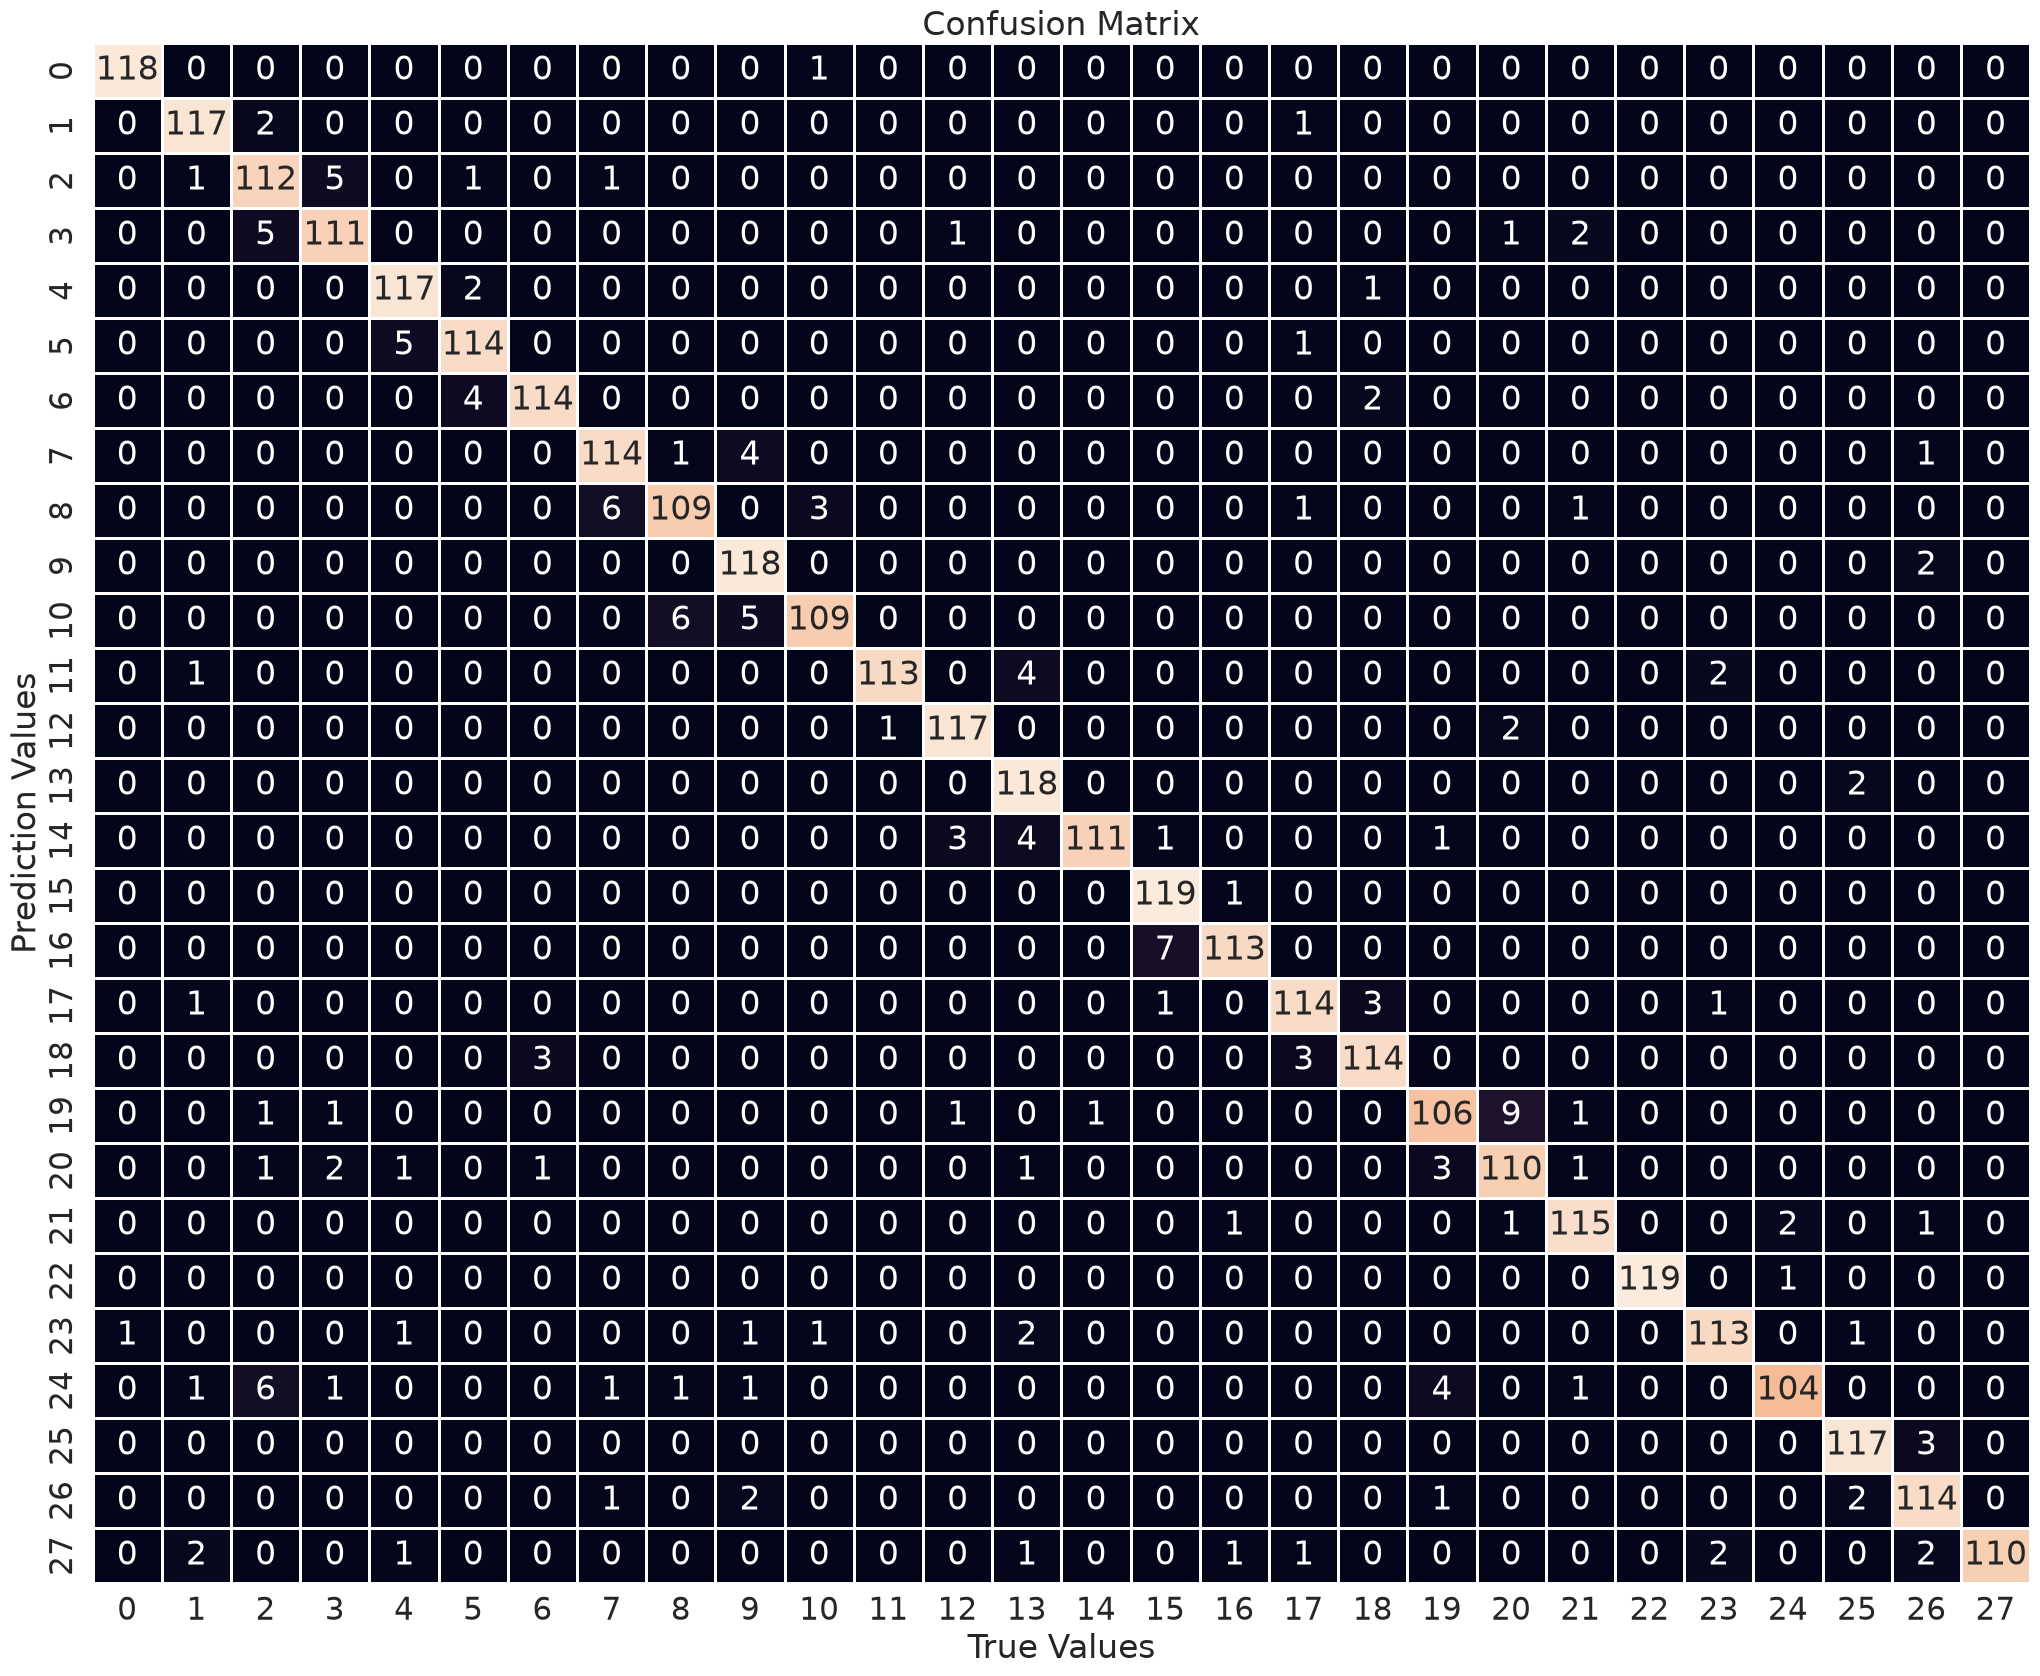

In [20]:
Y_pred = np.argmax(model.predict(X_test), axis=1)
cnf = confusion_matrix(y_test.argmax(axis=1), Y_pred)

df_cnf = pd.DataFrame(cnf, range(28), range(28))
sns.set(font_scale=2)
plt.figure(figsize=(25,20))
sns.heatmap(df_cnf, annot=True, linewidths=0.8, fmt='0.3g', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("True Values")
plt.ylabel("Prediction Values")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


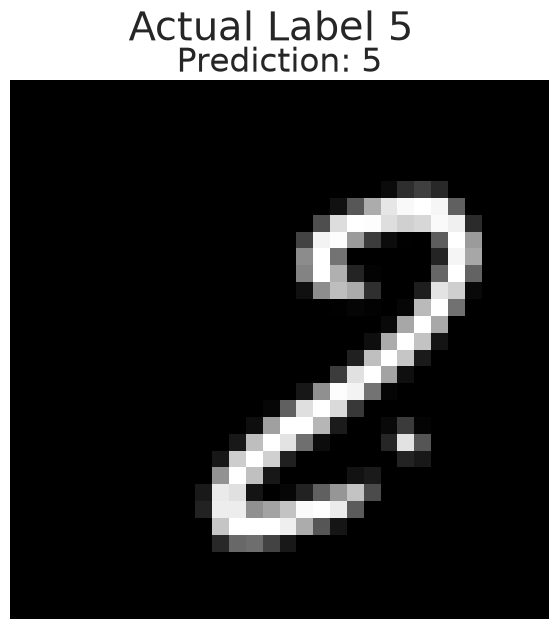

In [25]:
pred = np.argmax(model.predict(np.expand_dims(X_test[7], axis=0))) + 1
actual_label = np.argmax(y_test[7]) + 1

preds = "Prediction: " + str(pred)
plt.figure(figsize=(7,7))
plt.imshow(X_test[7].reshape(32, 32).T, cmap='gray')
plt.grid(False)
plt.axis("off")
plt.title(preds)
plt.suptitle("Actual Label " + str(acutual_label))
plt.show()

In [26]:
from tensorflow.keras.models import save_model
if os.path.isfile('best_model.h5') is False:
    model.save('best_model.h5')